In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
df = pd.read_csv('/content/dengue_dataset.csv')
print(f"Dataset loaded successfully")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"First 5 rows:\n{df.head()}")
print(f"\nData types:\n{df.dtypes}")

Dataset loaded successfully
Dataset shape: (200, 8)
Columns: ['Age', 'Gender', 'Fever', 'Headache', 'Platelet_Count', 'Hematocrit', 'District', 'Dengue_Result']
First 5 rows:
   Age  Gender Fever Headache  Platelet_Count  Hematocrit District  \
0   54  Female   Yes      Yes          224641        54.5    Dhaka   
1   57    Male    No      Yes          159639        34.4    Dhaka   
2   74  Female   Yes       No          225537        38.2    Dhaka   
3   77    Male   Yes      Yes          153709        47.0    Dhaka   
4   77    Male   Yes       No          169299        31.6    Dhaka   

   Dengue_Result  
0              1  
1              0  
2              1  
3              1  
4              1  

Data types:
Age                 int64
Gender             object
Fever              object
Headache           object
Platelet_Count      int64
Hematocrit        float64
District           object
Dengue_Result       int64
dtype: object


In [ ]:
print("Initial dataset info:")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

df_cleaned = df.copy()
df_cleaned = df_cleaned.drop_duplicates()

numerical_cols = df_cleaned.select_dtypes(include=[np.number]).columns
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

for col in numerical_cols:
    if df_cleaned[col].isnull().any():
        df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)

for col in categorical_cols:
    if df_cleaned[col].isnull().any():
        df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)

print("\nAfter cleaning:")
print(f"Dataset shape: {df_cleaned.shape}")
print(f"Missing values: {df_cleaned.isnull().sum().sum()}")
print(f"\nData types:")
print(df_cleaned.dtypes)

Initial dataset info:
Total rows: 200
Total columns: 8

Missing values per column:
Age               0
Gender            0
Fever             0
Headache          0
Platelet_Count    0
Hematocrit        0
District          0
Dengue_Result     0
dtype: int64

Duplicate rows: 0

After cleaning:
Dataset shape: (200, 8)
Missing values: 0

Data types:
Age                 int64
Gender             object
Fever              object
Headache           object
Platelet_Count      int64
Hematocrit        float64
District           object
Dengue_Result       int64
dtype: object


/tmp/ipython-input-2141203539.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[i], palette=colors)
/tmp/ipython-input-2141203539.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[i], palette=colors)
/tmp/ipython-input-2141203539.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[i], palette=colors)
/tmp/ipython-input-2141203539.py:19: FutureWarning: 

Passing `palette` without

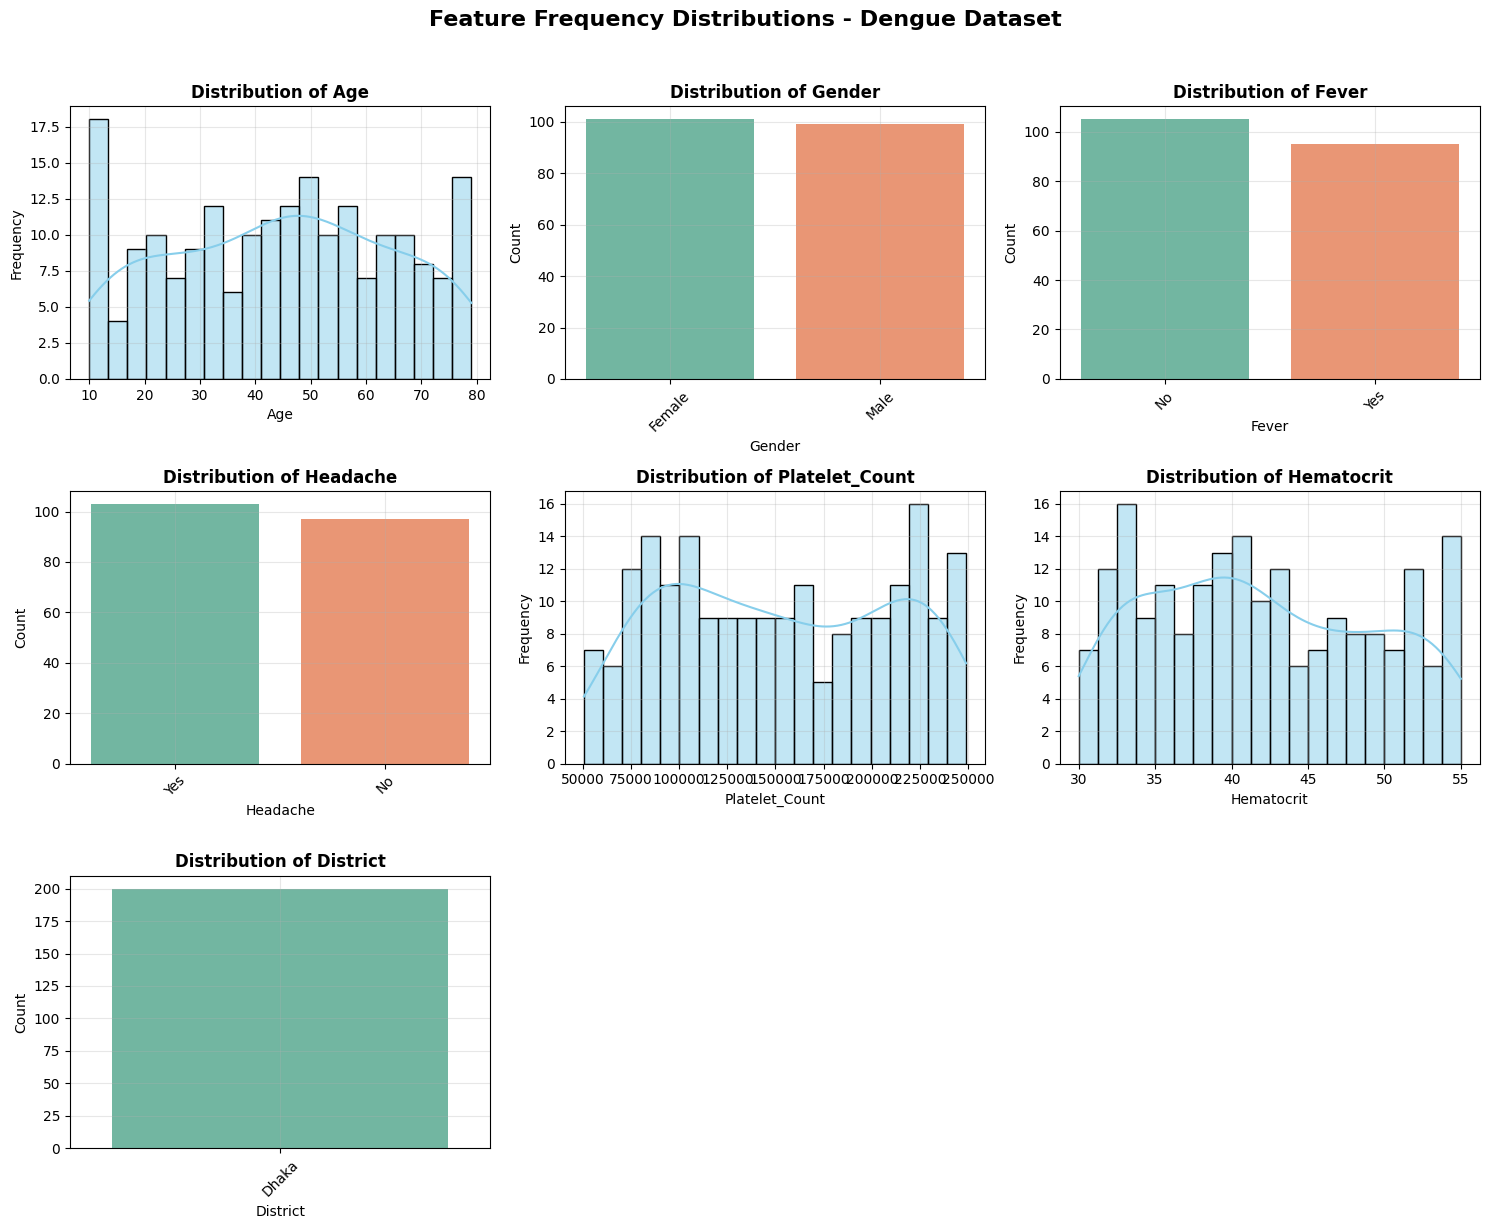

/tmp/ipython-input-2141203539.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x=target_col, palette=['#4ecdc4', '#ff6b6b'])


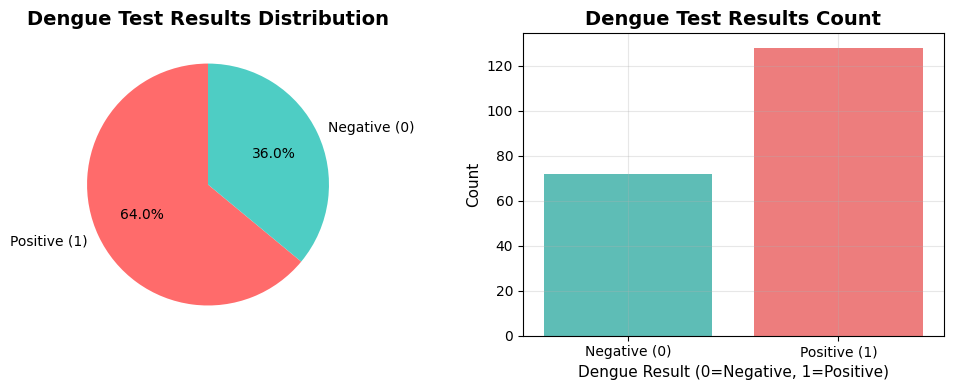

In [ ]:
feature_columns = df_cleaned.columns[:-1]
n_features = len(feature_columns)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.ravel()

for i, column in enumerate(feature_columns):
    if df_cleaned[column].dtype in ['int64', 'float64']:
        sns.histplot(data=df_cleaned, x=column, kde=True, ax=axes[i], bins=20, color='skyblue')
        axes[i].set_title(f'Distribution of {column}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(column, fontsize=10)
        axes[i].set_ylabel('Frequency', fontsize=10)
        axes[i].grid(True, alpha=0.3)
    else:
        value_counts = df_cleaned[column].value_counts()
        colors = sns.color_palette('Set2', len(value_counts))
        sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[i], palette=colors)
        axes[i].set_title(f'Distribution of {column}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(column, fontsize=10)
        axes[i].set_ylabel('Count', fontsize=10)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Frequency Distributions - Dengue Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

target_col = 'Dengue_Result'
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
result_counts = df_cleaned[target_col].value_counts()
colors = ['#ff6b6b', '#4ecdc4'] if len(result_counts) == 2 else None
plt.pie(result_counts.values, labels=['Positive (1)', 'Negative (0)'],
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Dengue Test Results Distribution', fontsize=14, fontweight='bold')

plt.subplot(1, 2, 2)
sns.countplot(data=df_cleaned, x=target_col, palette=['#4ecdc4', '#ff6b6b'])
plt.title('Dengue Test Results Count', fontsize=14, fontweight='bold')
plt.xlabel('Dengue Result (0=Negative, 1=Positive)', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.xticks([0, 1], ['Negative (0)', 'Positive (1)'])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
X = df_cleaned.drop(columns=['Dengue_Result'])
y = df_cleaned['Dengue_Result']

label_encoders_X = {}
categorical_features = X.select_dtypes(include=['object']).columns

print("Encoding categorical features:")
for column in categorical_features:
    le = LabelEncoder()
    X[column] = le.fit_transform(X[column])
    label_encoders_X[column] = le
    print(f"  {column}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nScaling completed:")
print(f"Original X shape: {X.shape}")
print(f"Scaled X shape: {X_scaled.shape}")
print(f"\nSample scaled data (first 3 rows):")
print(pd.DataFrame(X_scaled, columns=X.columns).head(3))

Encoding categorical features:
  Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  Fever: {'No': np.int64(0), 'Yes': np.int64(1)}
  Headache: {'No': np.int64(0), 'Yes': np.int64(1)}
  District: {'Dhaka': np.int64(0)}

Scaling completed:
Original X shape: (200, 7)
Scaled X shape: (200, 7)

Sample scaled data (first 3 rows):
        Age    Gender     Fever  Headache  Platelet_Count  Hematocrit  \
0  0.463943 -0.990050  1.051315  0.970437        1.230905    1.715832   
1  0.612563  1.010051 -0.951190  0.970437        0.119861   -1.040800   
2  1.454744 -0.990050  1.051315 -1.030464        1.246220   -0.519646   

   District  
0       0.0  
1       0.0  
2       0.0  


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=3327, stratify=y
)

print(f"Dataset Split Results:")
print("=" * 40)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(df_cleaned)*100:.1f}%)")
print(f"Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(df_cleaned)*100:.1f}%)")
print(f"Total features: {X_train.shape[1]}")
print(f"\nClass distribution in training set:")
print(f"  Negative (0): {np.sum(y_train == 0)} samples")
print(f"  Positive (1): {np.sum(y_train == 1)} samples")
print(f"\nClass distribution in testing set:")
print(f"  Negative (0): {np.sum(y_test == 0)} samples")
print(f"  Positive (1): {np.sum(y_test == 1)} samples")

Dataset Split Results:
Training set: 160 samples (80.0%)
Testing set: 40 samples (20.0%)
Total features: 7

Class distribution in training set:
  Negative (0): 58 samples
  Positive (1): 102 samples

Class distribution in testing set:
  Negative (0): 14 samples
  Positive (1): 26 samples


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=3327, stratify=y
)

print(f"Dataset Split Results:")
print("=" * 40)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(df_cleaned)*100:.1f}%)")
print(f"Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(df_cleaned)*100:.1f}%)")
print(f"Total features: {X_train.shape[1]}")
print(f"\nClass distribution in training set:")
print(f"  Negative (0): {np.sum(y_train == 0)} samples")
print(f"  Positive (1): {np.sum(y_train == 1)} samples")
print(f"\nClass distribution in testing set:")
print(f"  Negative (0): {np.sum(y_test == 0)} samples")
print(f"  Positive (1): {np.sum(y_test == 1)} samples")

Dataset Split Results:
Training set: 160 samples (80.0%)
Testing set: 40 samples (20.0%)
Total features: 7

Class distribution in training set:
  Negative (0): 58 samples
  Positive (1): 102 samples

Class distribution in testing set:
  Negative (0): 14 samples
  Positive (1): 26 samples


In [ ]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=3327, probability=True)
svm_model.fit(X_train, y_train)

print("SVM Classifier Training Complete")
print("=" * 40)
print(f"Model Type: {type(svm_model).__name__}")
print(f"Kernel: {svm_model.kernel}")
print(f"Regularization (C): {svm_model.C}")
print(f"Gamma: {svm_model.gamma}")
print(f"Number of Support Vectors: {len(svm_model.support_vectors_)}")
print(f"Number of Classes: {len(svm_model.classes_)}")
print(f"Classes: {svm_model.classes_}")

SVM Classifier Training Complete
Model Type: SVC
Kernel: rbf
Regularization (C): 1.0
Gamma: scale
Number of Support Vectors: 73
Number of Classes: 2
Classes: [0 1]


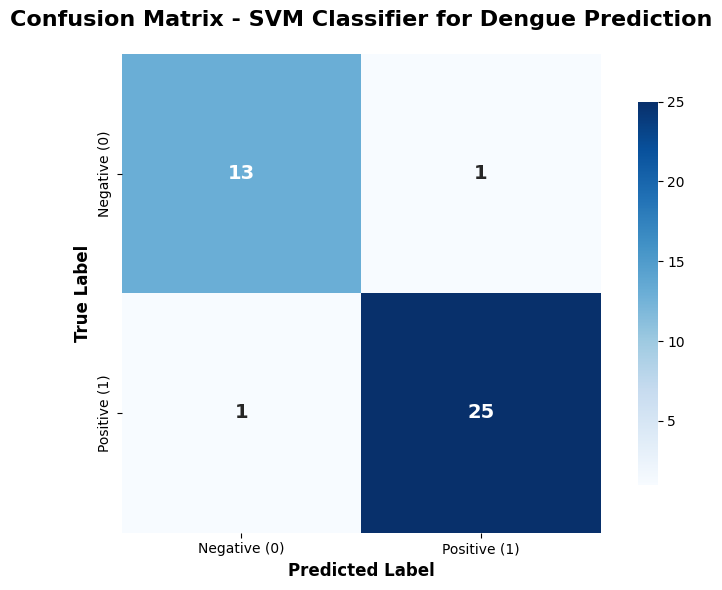

Confusion Matrix Analysis:
True Negatives  (TN): 13 - Correctly predicted negative cases
False Positives (FP): 1 - Negative cases predicted as positive
False Negatives (FN): 1 - Positive cases predicted as negative
True Positives  (TP): 25 - Correctly predicted positive cases

Total Predictions: 40

Performance Metrics:
  Accuracy:    0.9500 (95.00%)
  Precision:   0.9615 (96.15%)
  Recall:      0.9615 (96.15%)
  Specificity: 0.9286 (92.86%)
  F1-Score:    0.9615 (96.15%)


In [ ]:
y_pred = svm_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'],
            square=True,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix - SVM Classifier for Dengue Prediction', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("Confusion Matrix Analysis:")
print("=" * 50)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN): {tn} - Correctly predicted negative cases")
print(f"False Positives (FP): {fp} - Negative cases predicted as positive")
print(f"False Negatives (FN): {fn} - Positive cases predicted as negative")
print(f"True Positives  (TP): {tp} - Correctly predicted positive cases")
print(f"\nTotal Predictions: {np.sum(cm)}")

accuracy = (tp + tn) / np.sum(cm)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nPerformance Metrics:")
print(f"  Accuracy:    {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision:   {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:      {recall:.4f} ({recall*100:.2f}%)")
print(f"  Specificity: {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  F1-Score:    {f1_score:.4f} ({f1_score*100:.2f}%)")

Model Accuracy Comparison:
Training Accuracy: 0.9750 (97.50%)
Testing Accuracy:  0.9500 (95.00%)
Accuracy Difference: 0.0250


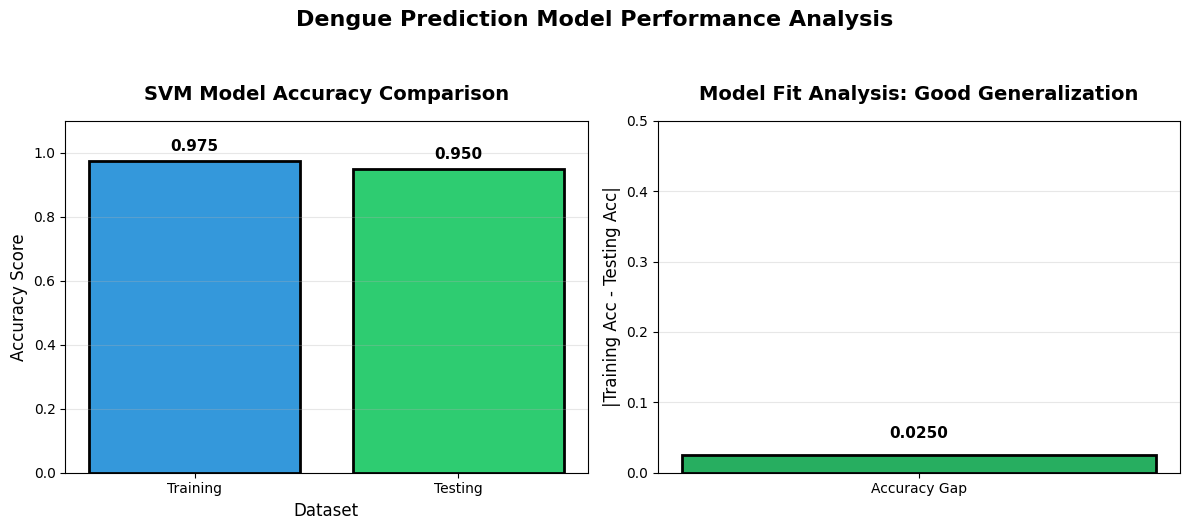


✓ GOOD: Model shows good generalization performance!
   Training and testing accuracies are similar.


In [ ]:
y_train_pred = svm_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy Comparison:")
print("=" * 40)
print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Testing Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Accuracy Difference: {abs(train_accuracy - test_accuracy):.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
acc_data = pd.DataFrame({
    'Dataset': ['Training', 'Testing'],
    'Accuracy': [train_accuracy, test_accuracy]
})
colors = ['#3498db', '#2ecc71']
bars = plt.bar(acc_data['Dataset'], acc_data['Accuracy'], color=colors, edgecolor='black', linewidth=2)
plt.title('SVM Model Accuracy Comparison', fontsize=14, fontweight='bold', pad=15)
plt.ylim([0, 1.1])
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Dataset', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

for bar, acc in zip(bars, [train_accuracy, test_accuracy]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.subplot(1, 2, 2)
accuracy_diff = train_accuracy - test_accuracy
if accuracy_diff > 0.05:
    diff_color = '#e74c3c'
    diff_label = 'Overfitting'
elif accuracy_diff < -0.05:
    diff_color = '#f39c12'
    diff_label = 'Underfitting'
else:
    diff_color = '#27ae60'
    diff_label = 'Good Generalization'

plt.bar(['Accuracy Gap'], [abs(accuracy_diff)], color=diff_color, edgecolor='black', linewidth=2)
plt.title(f'Model Fit Analysis: {diff_label}', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('|Training Acc - Testing Acc|', fontsize=12)
plt.ylim([0, 0.5])
plt.grid(True, alpha=0.3, axis='y')
plt.text(0, abs(accuracy_diff) + 0.02, f'{abs(accuracy_diff):.4f}',
         ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Dengue Prediction Model Performance Analysis', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

if accuracy_diff > 0.1:
    print("\n⚠️  WARNING: Significant overfitting detected!")
    print("   Training accuracy is much higher than testing accuracy.")
    print("   Consider using regularization or collecting more data.")
elif abs(accuracy_diff) < 0.05:
    print("\n✓ GOOD: Model shows good generalization performance!")
    print("   Training and testing accuracies are similar.")

10-Fold Cross-Validation Results:
CV Scores for each fold:
  Fold  1: 0.9000 (90.00%)
  Fold  2: 0.9000 (90.00%)
  Fold  3: 1.0000 (100.00%)
  Fold  4: 0.9500 (95.00%)
  Fold  5: 0.9000 (90.00%)
  Fold  6: 0.9000 (90.00%)
  Fold  7: 1.0000 (100.00%)
  Fold  8: 1.0000 (100.00%)
  Fold  9: 0.8000 (80.00%)
  Fold 10: 0.8000 (80.00%)

Mean CV Accuracy: 0.9150 (91.50%)
CV Accuracy Std Dev: 0.0709
CV Accuracy Range: [0.8000, 1.0000]

Previous Model Test Accuracy: 0.9500 (95.00%)
Difference (CV Mean - Test): -0.0350


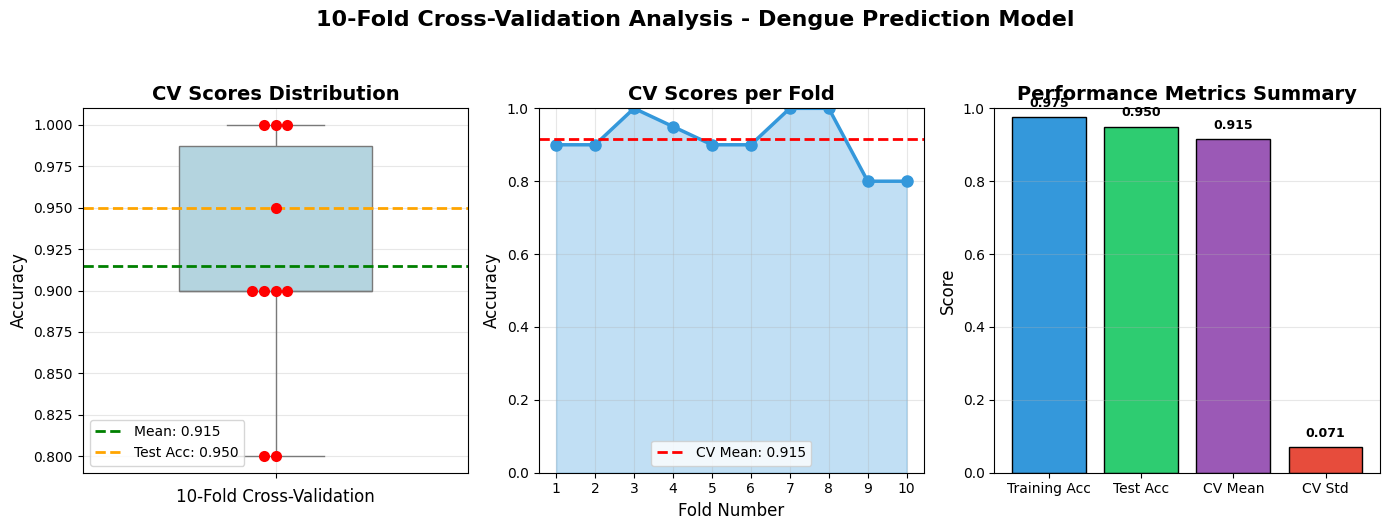


Model Performance Summary:
                       Metric    Score Percentage                   Interpretation
            Training Accuracy 0.975000     97.50%        Accuracy on training data
             Testing Accuracy 0.950000     95.00%     Accuracy on unseen test data
     10-Fold CV Mean Accuracy 0.915000     91.50% Average accuracy across 10 folds
10-Fold CV Standard Deviation 0.070887      7.09%  Variability in cross-validation


In [ ]:
cv_scores = cross_val_score(svm_model, X_scaled, y, cv=10, scoring='accuracy')

print("10-Fold Cross-Validation Results:")
print("=" * 50)
print(f"CV Scores for each fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i:2d}: {score:.4f} ({score*100:.2f}%)")

print(f"\nMean CV Accuracy: {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)")
print(f"CV Accuracy Std Dev: {cv_scores.std():.4f}")
print(f"CV Accuracy Range: [{cv_scores.min():.4f}, {cv_scores.max():.4f}]")
print(f"\nPrevious Model Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Difference (CV Mean - Test): {(cv_scores.mean() - test_accuracy):.4f}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=cv_scores, color='lightblue', width=0.5)
sns.swarmplot(y=cv_scores, color='red', size=8)
plt.title('CV Scores Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('10-Fold Cross-Validation', fontsize=12)
plt.axhline(y=cv_scores.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean: {cv_scores.mean():.3f}')
plt.axhline(y=test_accuracy, color='orange', linestyle='--', linewidth=2, label=f'Test Acc: {test_accuracy:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
fold_numbers = range(1, 11)
plt.plot(fold_numbers, cv_scores, marker='o', markersize=8, linewidth=2.5, color='#3498db')
plt.fill_between(fold_numbers, cv_scores, alpha=0.3, color='#3498db')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'CV Mean: {cv_scores.mean():.3f}')
plt.title('CV Scores per Fold', fontsize=14, fontweight='bold')
plt.xlabel('Fold Number', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(fold_numbers)
plt.ylim([0, 1])
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
performance_metrics = {
    'Metric': ['Training Acc', 'Test Acc', 'CV Mean', 'CV Std'],
    'Value': [train_accuracy, test_accuracy, cv_scores.mean(), cv_scores.std()],
    'Percentage': [f'{train_accuracy*100:.1f}%', f'{test_accuracy*100:.1f}%',
                   f'{cv_scores.mean()*100:.1f}%', f'{cv_scores.std()*100:.1f}%']
}
colors = ['#3498db', '#2ecc71', '#9b59b6', '#e74c3c']
bars = plt.bar(performance_metrics['Metric'], performance_metrics['Value'], color=colors, edgecolor='black')
plt.title('Performance Metrics Summary', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.ylim([0, 1])
for bar, val in zip(bars, performance_metrics['Value']):
    plt.text(bar.get_x() + bar.get_width()/2., val + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.suptitle('10-Fold Cross-Validation Analysis - Dengue Prediction Model',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("\nModel Performance Summary:")
print("=" * 50)
summary_df = pd.DataFrame({
    'Metric': ['Training Accuracy', 'Testing Accuracy',
               '10-Fold CV Mean Accuracy', '10-Fold CV Standard Deviation'],
    'Score': [train_accuracy, test_accuracy, cv_scores.mean(), cv_scores.std()],
    'Percentage': [f'{train_accuracy*100:.2f}%', f'{test_accuracy*100:.2f}%',
                   f'{cv_scores.mean()*100:.2f}%', f'{cv_scores.std()*100:.2f}%'],
    'Interpretation': [
        'Accuracy on training data',
        'Accuracy on unseen test data',
        'Average accuracy across 10 folds',
        'Variability in cross-validation'
    ]
})
print(summary_df.to_string(index=False))